# 🗂️ Unidad 2 — Estructuras de Datos
## Clase 1: Tipos de Datos Abstractos y Union-Find

---

> **Curso:** Estructuras de Datos y Algoritmos  
> **Duración:** 2 horas  
> **Prerequisitos:** Fundamentos de Python, listas, funciones

---

### 🗺️ Mapa de la clase

| # | Tema | Tiempo estimado |
|---|------|-----------------|
| 1 | ¿Qué es un Tipo de Dato Abstracto (TDA)? | 15 min |
| 2 | El problema de conectividad dinámica | 10 min |
| 3 | API de Union-Find | 10 min |
| 4 | Quick Find | 25 min |
| 5 | Quick Union | 25 min |
| 6 | Comparación y análisis de costo | 15 min |
| 7 | Ejercicios | 20 min |

---

## 1. ¿Qué es un Tipo de Dato Abstracto (TDA)?

Un **Tipo de Dato Abstracto (TDA)** —o *Abstract Data Type (ADT)* en inglés— es una forma de pensar sobre los datos **separando el *qué* del *cómo***:

| Dimensión | Pregunta | Responsable |
|-----------|----------|-------------|
| **Interfaz (API)** | ¿Qué operaciones puedo hacer? | El diseñador / usuario |
| **Implementación** | ¿Cómo se ejecutan esas operaciones? | El programador |

### Analogía: Un cajero automático 🏧

Tú sabes que puedes *depositar*, *retirar* y *consultar saldo*, pero **no sabes** (ni necesitas saber) cómo el banco guarda esa información internamente. Eso es abstracción.

### ¿Por qué importa en esta unidad?

Cada estructura de datos que estudiaremos tiene:
1. Una **API clara** (contrato con el usuario)
2. **Una o más implementaciones** con distintos costos
3. **Casos de uso** donde una implementación es mejor que otra

```
     ┌─────────────────────────────────────┐
     │           INTERFAZ (API)            │
     │   union(p, q)   connected(p, q)     │
     └──────────────┬──────────────────────┘
                    │ oculta los detalles
          ┌─────────┴──────────┐
          │                    │
   Quick Find            Quick Union
  (implementación 1)  (implementación 2)
```

---

## 2. El Problema: Conectividad Dinámica

Imagina que tienes **N objetos** (nodos, computadores, personas, píxeles…).

Necesitas responder eficientemente dos tipos de preguntas:

- **`union(p, q)`** → Conectar el objeto `p` con el objeto `q`
- **`connected(p, q)`** → ¿Existe algún camino que conecte `p` con `q`?

### Ejemplos del mundo real

| Dominio | Objetos | Conexión |
|---------|---------|----------|
| Redes de computadores | Servidores | Cable / WiFi |
| Redes sociales | Personas | Amistad |
| Chips electrónicos | Transistores | Conductores |
| Juego Percolation | Celdas de grilla | Apertura |

### Propiedades de "estar conectado"

La relación de conectividad es una **relación de equivalencia**, lo que implica:

- **Reflexiva:** `p` está conectado consigo mismo
- **Simétrica:** Si `p` está conectado con `q`, entonces `q` está conectado con `p`
- **Transitiva:** Si `p–q` y `q–r`, entonces `p–r`

Esto nos permite agrupar objetos en **componentes conectados** (conjuntos disjuntos).

### Visualización inicial

```
Objetos:  0  1  2  3  4  5  6  7  8  9

Antes de cualquier unión → cada objeto es su propio componente:
{0} {1} {2} {3} {4} {5} {6} {7} {8} {9}

Después de union(4,3), union(3,8), union(6,5):
{0} {1} {2} {3,4,8} {5,6} {7} {9}
```

---

## 3. API de Union-Find

Definimos el **contrato** de nuestra estructura antes de escribir una sola línea de implementación.

```
╔══════════════════════════════════════════════════════╗
║              API  —  Union Find                      ║
╠══════════════════════════════════════════════════════╣
║  UF(n)              Inicializar con n objetos (0..n-1)║
║  union(p, q)        Agregar conexión entre p y q     ║
║  connected(p, q)    ¿Están p y q en el mismo         ║
║                     componente conectado?             ║
║  find(p)            Retorna el id del componente      ║
║                     al que pertenece p               ║
║  count()            Número de componentes            ║
╚══════════════════════════════════════════════════════╝
```

> **Nota:** La API es la misma para Quick Find y Quick Union. Lo que cambia es la implementación interna.

In [1]:
# 📋 Clase base abstracta — define la interfaz (el contrato)
# Todos los Union-Find deben implementar estos métodos

from abc import ABC, abstractmethod

class UnionFind(ABC):
    """
    Tipo de Dato Abstracto: Union-Find (Conjuntos Disjuntos)
    Resuelve el problema de conectividad dinámica.
    """

    @abstractmethod
    def union(self, p: int, q: int) -> None:
        """Conecta el componente que contiene p con el que contiene q."""
        pass

    @abstractmethod
    def find(self, p: int) -> int:
        """Retorna el identificador del componente al que pertenece p."""
        pass

    def connected(self, p: int, q: int) -> bool:
        """Retorna True si p y q están en el mismo componente."""
        return self.find(p) == self.find(q)   # ← reutiliza find()

    @abstractmethod
    def count(self) -> int:
        """Retorna el número de componentes conectados."""
        pass

print("✅ Clase abstracta UnionFind definida correctamente")

✅ Clase abstracta UnionFind definida correctamente


> 💡 **Punto clave:** `connected()` está implementado en la clase base usando `find()`. Esto significa que cualquier subclase que implemente `find()` **hereda** `connected()` gratis. Esto es el poder de la abstracción.

---

## 4. Quick Find

### Idea principal

Mantener un arreglo `id[]` donde **`id[p]` es el identificador del componente de `p`**.

- Dos objetos `p` y `q` están conectados **si y solo si** `id[p] == id[q]`
- `find(p)` es trivial: retorna `id[p]` → **O(1)**
- `union(p, q)` debe actualizar todos los que tenían el id de `p` → **O(N)**

### Ejemplo paso a paso

```
Inicial (N=10):
índice:  0  1  2  3  4  5  6  7  8  9
id[]:    0  1  2  3  4  5  6  7  8  9

union(4, 3):  todos los id[i]==4 pasan a ser 3
id[]:    0  1  2  3  3  5  6  7  8  9
                  ↑  ↑
union(3, 8):  todos los id[i]==3 pasan a ser 8
id[]:    0  1  2  8  8  5  6  7  8  9
                  ↑  ↑        ↑
union(6, 5):  todos los id[i]==6 pasan a ser 5
id[]:    0  1  2  8  8  5  5  7  8  9
                           ↑  ↑
connected(4, 8)?  id[4]=8, id[8]=8  → True ✅
connected(4, 6)?  id[4]=8, id[6]=5  → False ❌
```

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPLEMENTACIÓN: Quick Find
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class QuickFind(UnionFind):
    """
    Quick Find: find es O(1), union es O(N).
    
    Estructura interna:
        id[i] = identificador del componente al que pertenece i
    Invariante:
        p y q están conectados  <=>  id[p] == id[q]
    """

    def __init__(self, n: int):
        # Cada objeto empieza siendo su propio componente
        self._id = list(range(n))   # id[i] = i
        self._count = n             # n componentes al inicio

    def find(self, p: int) -> int:
        """O(1) — acceso directo al arreglo."""
        return self._id[p]

    def union(self, p: int, q: int) -> None:
        """
        O(N) — debe recorrer todo el arreglo.
        Cambia todos los id[] que coincidan con pid al valor qid.
        """
        pid = self.find(p)   # componente de p
        qid = self.find(q)   # componente de q

        if pid == qid:       # ya están conectados → no hacer nada
            return

        # Recorrer todo el arreglo y reemplazar pid → qid
        for i in range(len(self._id)):
            if self._id[i] == pid:
                self._id[i] = qid

        self._count -= 1     # se redujo un componente

    def count(self) -> int:
        return self._count

    def __repr__(self):
        return f"id[] = {self._id}  |  componentes = {self._count}"


print("✅ Clase QuickFind definida")

✅ Clase QuickFind definida


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DEMOSTRACIÓN: Quick Find en acción
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 55)
print("  DEMO Quick Find — N = 10 objetos")
print("=" * 55)

qf = QuickFind(10)
print(f"\nInicial:    {qf}")

operaciones = [
    ("union", 4, 3),
    ("union", 3, 8),
    ("union", 6, 5),
    ("union", 9, 4),
    ("union", 2, 1),
]

for op, p, q in operaciones:
    qf.union(p, q)
    print(f"union({p},{q}) → {qf}")

print()
consultas = [(0, 7), (8, 9), (5, 4), (3, 4)]
for p, q in consultas:
    resultado = qf.connected(p, q)
    simbolo = "✅" if resultado else "❌"
    print(f"connected({p},{q}) = {resultado}  {simbolo}")

  DEMO Quick Find — N = 10 objetos

Inicial:    id[] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  |  componentes = 10
union(4,3) → id[] = [0, 1, 2, 3, 3, 5, 6, 7, 8, 9]  |  componentes = 9
union(3,8) → id[] = [0, 1, 2, 8, 8, 5, 6, 7, 8, 9]  |  componentes = 8
union(6,5) → id[] = [0, 1, 2, 8, 8, 5, 5, 7, 8, 9]  |  componentes = 7
union(9,4) → id[] = [0, 1, 2, 8, 8, 5, 5, 7, 8, 8]  |  componentes = 6
union(2,1) → id[] = [0, 1, 1, 8, 8, 5, 5, 7, 8, 8]  |  componentes = 5

connected(0,7) = False  ❌
connected(8,9) = True  ✅
connected(5,4) = False  ❌
connected(3,4) = True  ✅


### Visualización: estado del arreglo `id[]`

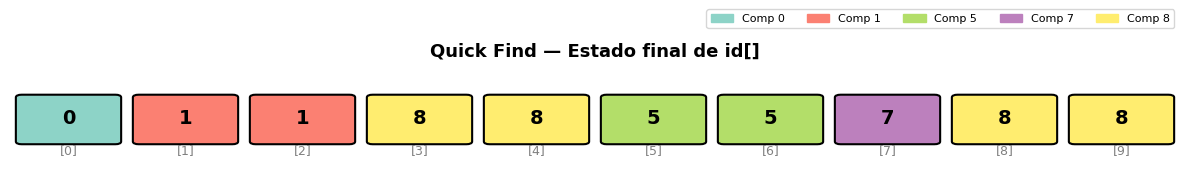

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualizar_id(id_arr, titulo="Estado de id[]"):
    """
    Grafica el arreglo id[] coloreando cada componente de un color distinto.
    """
    n = len(id_arr)
    componentes = list(set(id_arr))
    colores_base = plt.cm.Set3(np.linspace(0, 1, len(componentes)))
    color_map = {comp: colores_base[i] for i, comp in enumerate(componentes)}

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, 1.5)
    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)

    for i, val in enumerate(id_arr):
        color = color_map[val]
        rect = mpatches.FancyBboxPatch(
            (i - 0.4, 0.2), 0.8, 0.8,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor='black', linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(i, 0.62, str(val), ha='center', va='center', fontsize=14, fontweight='bold')
        ax.text(i, 0.05, f"[{i}]", ha='center', va='center', fontsize=9, color='gray')

    # Leyenda de componentes
    patches = [mpatches.Patch(color=color_map[c], label=f'Comp {c}') for c in sorted(componentes)]
    ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1, 1.6),
              ncol=len(componentes), fontsize=8, framealpha=0.8)
    plt.tight_layout()
    plt.show()


# Estado final del Quick Find de la demo
visualizar_id(qf._id, titulo="Quick Find — Estado final de id[]")

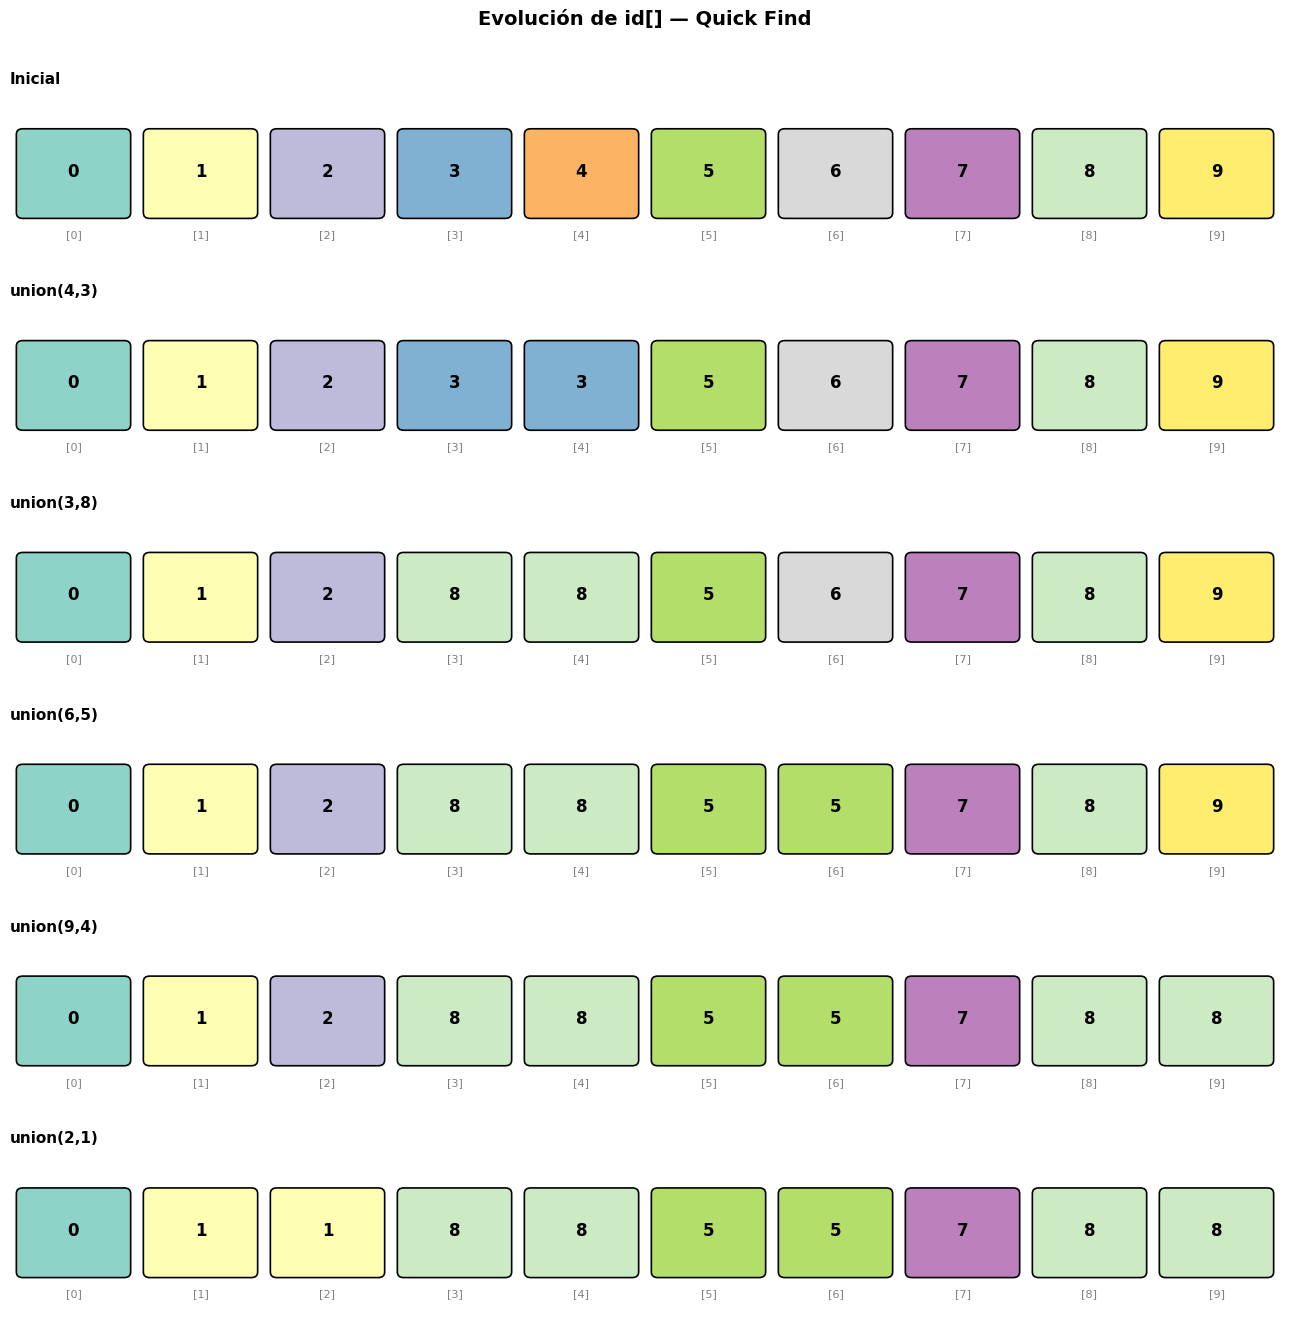

In [5]:
# Evolución paso a paso del arreglo id[]

estados = []
titulos = []

qf2 = QuickFind(10)
estados.append(list(qf2._id))
titulos.append("Inicial")

pasos = [(4,3), (3,8), (6,5), (9,4), (2,1)]
for p, q in pasos:
    qf2.union(p, q)
    estados.append(list(qf2._id))
    titulos.append(f"union({p},{q})")

# Graficamos todos los estados
fig, axes = plt.subplots(len(estados), 1, figsize=(13, 2.2 * len(estados)))

componentes_global = list(range(10))  # usamos índice como color base

for ax, id_arr, titulo in zip(axes, estados, titulos):
    n = len(id_arr)
    comps = list(set(id_arr))
    colores = plt.cm.Set3(np.linspace(0, 1, 10))
    color_map = {c: colores[c] for c in range(10)}

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.2, 1.4)
    ax.axis('off')
    ax.set_title(titulo, fontsize=11, fontweight='bold', loc='left', pad=4)

    for i, val in enumerate(id_arr):
        rect = mpatches.FancyBboxPatch(
            (i - 0.4, 0.3), 0.8, 0.7,
            boxstyle="round,pad=0.05",
            facecolor=color_map[val], edgecolor='black', linewidth=1.2
        )
        ax.add_patch(rect)
        ax.text(i, 0.67, str(val), ha='center', va='center', fontsize=12, fontweight='bold')
        ax.text(i, 0.1, f"[{i}]", ha='center', va='center', fontsize=8, color='gray')

plt.suptitle("Evolución de id[] — Quick Find", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### ⚠️ El problema de Quick Find

**`union()` es demasiado lento.** Si realizamos N operaciones `union` sobre N objetos:

```
Costo total ≈ N × N = N²  accesos al arreglo
```

Para N = 10⁹ objetos (escala moderna) → **10¹⁸ operaciones** → inviable.

| Operación | Quick Find |
|-----------|------------|
| `find(p)` | O(1) |
| `union(p, q)` | **O(N)** ← cuello de botella |
| `connected(p, q)` | O(1) |

---

## 5. Quick Union

### Idea principal: árboles perezosos

Usamos el mismo arreglo `id[]`, pero ahora lo interpretamos como un **bosque de árboles**:

- `id[i]` = **padre de `i`** en el árbol
- Si `id[i] == i` → `i` es la **raíz** de su árbol (su propio padre)
- Cada árbol representa un componente conectado
- La **raíz** del árbol es el identificador del componente

```
Arreglo id[]:
 índice:  0  1  2  3  4  5  6  7  8  9
 id[]:    0  1  9  4  9  6  6  7  8  9

Árbol resultante:
          9        6        0  1  7  8
         / \       |
        2   4      5
            |
            3
```

### Operaciones

- **`find(p)`:** Seguir los punteros padre hasta llegar a la raíz → **O(profundidad)**
- **`union(p, q)`:** Encontrar raíces de p y q, hacer que una apunte a la otra → **O(profundidad)**

```
union(p, q):   find raíz de p → rp
               find raíz de q → rq
               id[rp] = rq         ← solo UN cambio
```

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPLEMENTACIÓN: Quick Union
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class QuickUnion(UnionFind):
    """
    Quick Union: árbol con estructura de bosque.
    
    Estructura interna:
        id[i] = padre de i en el árbol
        id[i] == i  <=>  i es raíz
    
    Costo: O(profundidad) para find y union.
    Problema: el árbol puede degenerar en lista enlazada.
    """

    def __init__(self, n: int):
        # Al inicio, cada nodo apunta a sí mismo (es su propia raíz)
        self._id = list(range(n))   # id[i] = i
        self._count = n

    def _root(self, p: int) -> int:
        """
        Seguir los punteros padre hasta llegar a la raíz.
        La raíz se reconoce porque id[raíz] == raíz.
        O(profundidad del árbol)
        """
        while self._id[p] != p:      # mientras p no sea raíz
            p = self._id[p]          # subir un nivel hacia la raíz
        return p

    def find(self, p: int) -> int:
        """La identidad del componente es la raíz del árbol."""
        return self._root(p)

    def union(self, p: int, q: int) -> None:
        """
        O(profundidad) — solo cambia UN elemento del arreglo.
        Hace que la raíz de p apunte a la raíz de q.
        """
        rp = self._root(p)   # raíz del árbol de p
        rq = self._root(q)   # raíz del árbol de q

        if rp == rq:         # ya están en el mismo árbol
            return

        self._id[rp] = rq    # ← ¡solo UN cambio!
        self._count -= 1

    def count(self) -> int:
        return self._count

    def __repr__(self):
        return f"id[] = {self._id}  |  componentes = {self._count}"


print("✅ Clase QuickUnion definida")

✅ Clase QuickUnion definida


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DEMOSTRACIÓN: Quick Union en acción
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 55)
print("  DEMO Quick Union — N = 10 objetos")
print("=" * 55)

qu = QuickUnion(10)
print(f"\nInicial:    {qu}")

for op, p, q in operaciones:   # mismas operaciones que antes
    qu.union(p, q)
    print(f"union({p},{q}) → {qu}")

print()
for p, q in consultas:
    resultado = qu.connected(p, q)
    simbolo = "✅" if resultado else "❌"
    print(f"connected({p},{q}) = {resultado}  {simbolo}")

  DEMO Quick Union — N = 10 objetos

Inicial:    id[] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  |  componentes = 10
union(4,3) → id[] = [0, 1, 2, 3, 3, 5, 6, 7, 8, 9]  |  componentes = 9
union(3,8) → id[] = [0, 1, 2, 8, 3, 5, 6, 7, 8, 9]  |  componentes = 8
union(6,5) → id[] = [0, 1, 2, 8, 3, 5, 5, 7, 8, 9]  |  componentes = 7
union(9,4) → id[] = [0, 1, 2, 8, 3, 5, 5, 7, 8, 8]  |  componentes = 6
union(2,1) → id[] = [0, 1, 1, 8, 3, 5, 5, 7, 8, 8]  |  componentes = 5

connected(0,7) = False  ❌
connected(8,9) = True  ✅
connected(5,4) = False  ❌
connected(3,4) = True  ✅


In [ ]:
#!pip install networkx

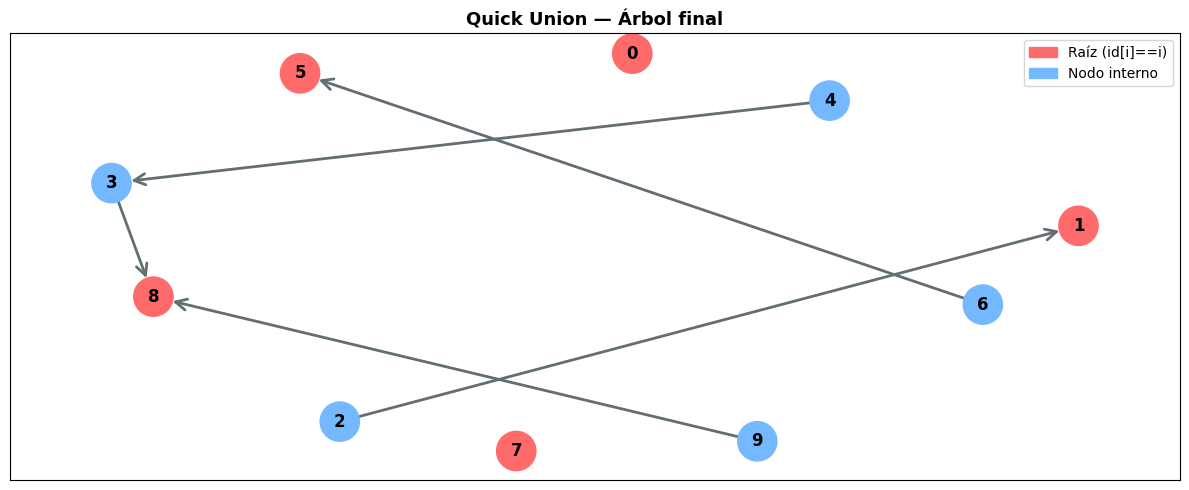

In [9]:
import networkx as nx

def visualizar_arbol_qu(id_arr, titulo="Quick Union — Estructura de árbol"):
    """
    Visualiza el bosque de árboles implícito en el arreglo id[] de Quick Union.
    """
    n = len(id_arr)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))

    raices = set()
    for i in range(n):
        if id_arr[i] != i:
            G.add_edge(i, id_arr[i])   # hijo → padre
        else:
            raices.add(i)

    # Colores: raíces en rojo, resto azul claro
    colores_nodos = ['#ff6b6b' if i in raices else '#74b9ff' for i in range(n)]

    # Layout jerárquico (de arriba hacia abajo)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=2)

    fig, ax = plt.subplots(figsize=(12, 5))
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=colores_nodos, node_size=800,
        font_size=12, font_weight='bold', font_color='black',
        arrows=True, arrowstyle='->', arrowsize=20,
        edge_color='#636e72', width=2
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold')

    # Leyenda
    raiz_patch = mpatches.Patch(color='#ff6b6b', label='Raíz (id[i]==i)')
    nodo_patch = mpatches.Patch(color='#74b9ff', label='Nodo interno')
    ax.legend(handles=[raiz_patch, nodo_patch], loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()


visualizar_arbol_qu(qu._id, "Quick Union — Árbol final")

### ⚠️ El problema de Quick Union

El árbol puede volverse **muy alto** (degenerar). En el peor caso, todos los nodos forman una cadena lineal:

```
union(0,1), union(0,2), union(0,3), union(0,4) ...

    4
    |
    3
    |
    2
    |
    1
    |
    0   ← raíz
```

En ese caso `find(4)` tarda **N pasos** → O(N), igual de lento que Quick Find.

| Operación | Quick Find | Quick Union |
|-----------|------------|-------------|
| `find(p)` | O(1) | O(N) peor caso |
| `union(p, q)` | O(N) | O(N) peor caso |
| `connected(p, q)` | O(1) | O(N) peor caso |

Secuencia que genera árbol degenerado:
Inicial: id[] = [0, 1, 2, 3, 4, 5]  |  componentes = 6
union(5,4) → id[] = [0, 1, 2, 3, 4, 4]  |  componentes = 5
union(4,3) → id[] = [0, 1, 2, 3, 3, 4]  |  componentes = 4
union(3,2) → id[] = [0, 1, 2, 2, 3, 4]  |  componentes = 3
union(2,1) → id[] = [0, 1, 1, 2, 3, 4]  |  componentes = 2
union(1,0) → id[] = [0, 0, 1, 2, 3, 4]  |  componentes = 1

Árbol resultante:


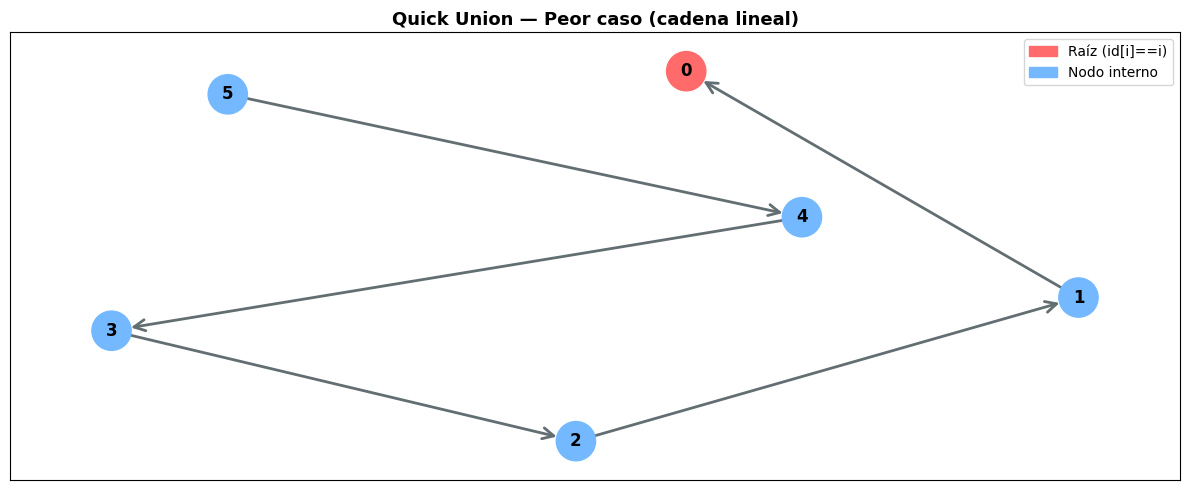

In [10]:
# Demostración del peor caso de Quick Union

qu_peor = QuickUnion(6)
print("Secuencia que genera árbol degenerado:")
print(f"Inicial: {qu_peor}")

for i in range(5, 0, -1):          # 5→4, 4→3, 3→2, 2→1, 1→0
    qu_peor.union(i, i-1)
    print(f"union({i},{i-1}) → {qu_peor}")

print()
print("Árbol resultante:")
visualizar_arbol_qu(qu_peor._id, "Quick Union — Peor caso (cadena lineal)")

---

## 6. Comparación y Análisis de Costo

### Tabla comparativa: accesos al arreglo `id[]`

| Algoritmo | Inicializar | `union` | `find` |
|-----------|-------------|---------|--------|
| **Quick Find** | N | N | 1 |
| **Quick Union** | N | N† | N† |

> † incluye el costo de `find`. En el peor caso el árbol tiene altura N.

### ¿Cuándo conviene cada uno?

| Situación | Mejor opción |
|-----------|-------------|
| Muchas consultas `connected`, pocas uniones | **Quick Find** |
| Pocos elementos, árbol balanceado esperado | **Quick Union** |
| Producción / gran escala | **Weighted Quick Union + Path Compression** (próxima clase) |

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Benchmark: comparación empírica de tiempos
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import time
import random

def benchmark(clase, n, operaciones_union, operaciones_find, semilla=42):
    """Mide el tiempo de N operaciones union y find."""
    random.seed(semilla)
    uf = clase(n)

    pares_union = [(random.randint(0, n-1), random.randint(0, n-1))
                   for _ in range(operaciones_union)]
    pares_find  = [(random.randint(0, n-1), random.randint(0, n-1))
                   for _ in range(operaciones_find)]

    inicio = time.perf_counter()
    for p, q in pares_union:
        uf.union(p, q)
    for p, q in pares_find:
        uf.connected(p, q)
    fin = time.perf_counter()

    return fin - inicio


tamanios = [500, 1000, 2000, 4000, 8000]
tiempos_qf = []
tiempos_qu = []

for n in tamanios:
    t_qf = benchmark(QuickFind,  n, n, n*2)
    t_qu = benchmark(QuickUnion, n, n, n*2)
    tiempos_qf.append(t_qf * 1000)
    tiempos_qu.append(t_qu * 1000)
    print(f"N={n:5d}  |  QuickFind: {t_qf*1000:6.2f} ms  |  QuickUnion: {t_qu*1000:6.2f} ms")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tamanios, tiempos_qf, 'o-', color='#e17055', linewidth=2, markersize=7, label='Quick Find')
ax.plot(tamanios, tiempos_qu, 's-', color='#0984e3', linewidth=2, markersize=7, label='Quick Union')
ax.set_xlabel('N (tamaño del problema)', fontsize=12)
ax.set_ylabel('Tiempo (ms)', fontsize=12)
ax.set_title('Quick Find vs Quick Union — Tiempo vs N', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 7. Ejercicios 💪

### Ejercicio 1 — Trazar a mano

Dado un arreglo inicial con `N = 8` objetos, aplica las siguientes operaciones de **Quick Find** y dibuja el arreglo `id[]` después de cada paso:

```
union(0, 2)
union(1, 3)
union(0, 3)
union(4, 7)
union(3, 5)
```

¿Cuántos componentes quedan? ¿Es `connected(2, 5)` verdadero?

---

### Ejercicio 2 — Código

Completa la función `union_sequence` que recibe una lista de pares y devuelve:
- El número de componentes final
- El contenido del arreglo `id[]`

In [ ]:
# EJERCICIO 2 — completa las líneas marcadas con TODO

def union_sequence(n: int, pares: list, algoritmo) -> dict:
    """
    Aplica una secuencia de uniones y retorna el estado final.
    
    Parámetros:
        n        : número de objetos
        pares    : lista de tuplas (p, q) a unir
        algoritmo: QuickFind o QuickUnion
    """
    uf = algoritmo(n)

    for p, q in pares:
        # TODO: aplica la unión
        pass

    return {
        "componentes": None,    # TODO: obtén el número de componentes
        "id": None,             # TODO: retorna el arreglo id[]
    }


# Prueba tu solución:
pares_prueba = [(0,2), (1,3), (0,3), (4,7), (3,5)]

resultado_qf = union_sequence(8, pares_prueba, QuickFind)
resultado_qu = union_sequence(8, pares_prueba, QuickUnion)

print("Quick Find  →", resultado_qf)
print("Quick Union →", resultado_qu)

In [ ]:
# SOLUCIÓN EJERCICIO 2 — ejecuta solo después de intentarlo

def union_sequence_sol(n, pares, algoritmo):
    uf = algoritmo(n)
    for p, q in pares:
        uf.union(p, q)
    return {"componentes": uf.count(), "id": uf._id}

r_qf = union_sequence_sol(8, pares_prueba, QuickFind)
r_qu = union_sequence_sol(8, pares_prueba, QuickUnion)

print("✅ Quick Find  →", r_qf)
print("✅ Quick Union →", r_qu)

# Verificación
qf_test = QuickFind(8)
for p, q in pares_prueba:
    qf_test.union(p, q)
print(f"\nconnected(2, 5) con QuickFind = {qf_test.connected(2, 5)}")

### Ejercicio 3 — Análisis crítico

Considera la siguiente afirmación:

> *"Quick Union siempre es mejor que Quick Find porque `union()` solo modifica un elemento del arreglo."*

**¿Es correcta esta afirmación?** Justifica tu respuesta con un contraejemplo o con análisis de casos.

---

### Ejercicio 4 — Para pensar 🧠 (Challenge)

¿Cómo modificarías `QuickUnion` para que el árbol no crezca demasiado?
Pista: piensa en qué árbol conviene hacer raíz del otro durante `union()`.

*(Esta mejora se llama **Weighted Quick Union** y la estudiaremos en la próxima clase.)*

---

## 📌 Resumen de la clase

| Concepto | Definición corta |
|----------|------------------|
| **TDA** | Separación entre *qué* hace una estructura y *cómo* lo hace |
| **Conectividad dinámica** | Problema de mantener componentes conectados con `union` y `connected` |
| **Quick Find** | `id[p]` = componente. `find` O(1), `union` O(N) |
| **Quick Union** | `id[p]` = padre. Árbol implícito. Ambas O(profundidad), peor caso O(N) |
| **Próximo paso** | Weighted Quick Union + Path Compression → O(log N) y O(α(N)) |

---

### 📚 Bibliografía

- Sedgewick, R. & Wayne, K. *Algorithms, 4th Edition*. Princeton. (Capítulo 1.5)
- Coursera: [Algorithms Part I — Union Find](https://www.coursera.org/learn/algorithms-part1)

---
*Notebook preparado para la Unidad 2 — Estructuras de Datos*